# Lab Task 3: Morphological Gradient

## Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load Image

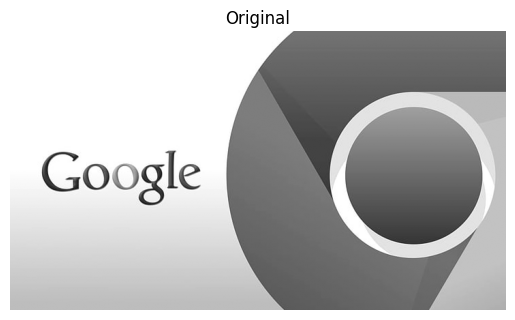

In [2]:
img = cv2.imread('../CVLab02/assets/google.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off'); plt.show()

## Morphological Gradient

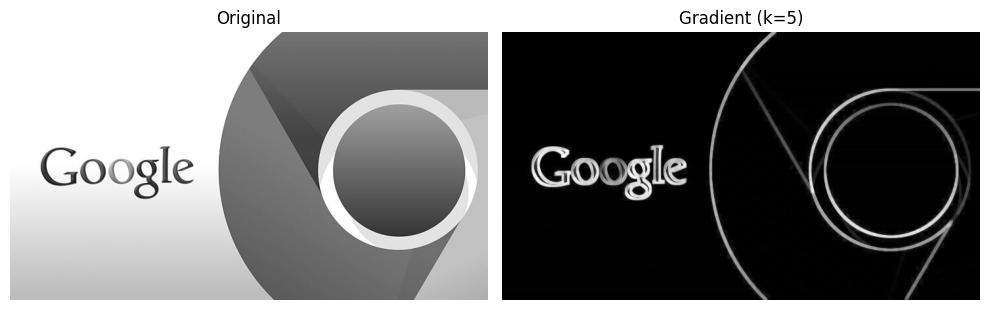

In [3]:
# Gradient = Dilation - Erosion
# Highlights the boundary/outline of objects

kernel   = np.ones((5, 5), np.uint8)
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img,      cmap='gray'); axes[0].set_title('Original');             axes[0].axis('off')
axes[1].imshow(gradient, cmap='gray'); axes[1].set_title('Gradient (k=5)');       axes[1].axis('off')
plt.tight_layout(); plt.show()

## Different Structuring Elements

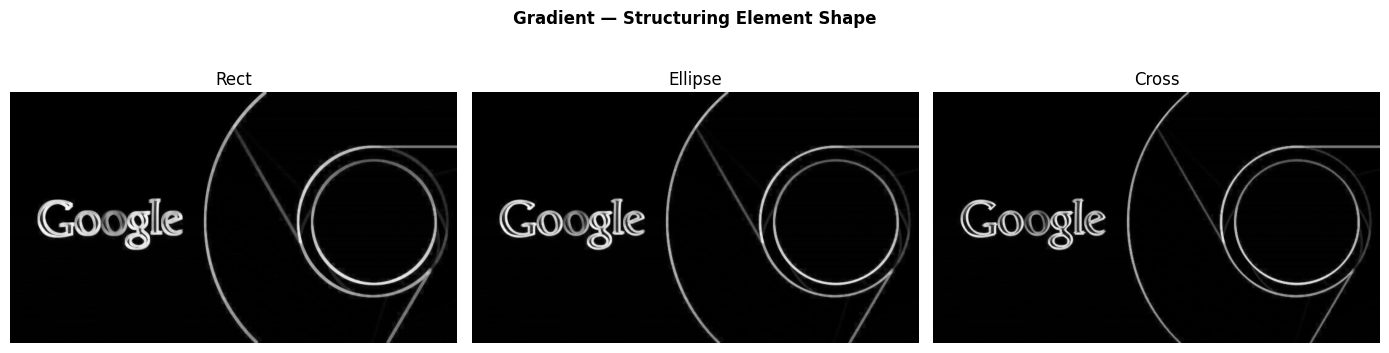

In [4]:
rect  = cv2.getStructuringElement(cv2.MORPH_RECT,    (5, 5))
ellip = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cross = cv2.getStructuringElement(cv2.MORPH_CROSS,   (5, 5))

grad_rect  = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, rect)
grad_ellip = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, ellip)
grad_cross = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, cross)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Gradient — Structuring Element Shape', fontweight='bold')
for ax, res, t in zip(axes, [grad_rect, grad_ellip, grad_cross], ['Rect', 'Ellipse', 'Cross']):
    ax.imshow(res, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

## Kernel Size Effect

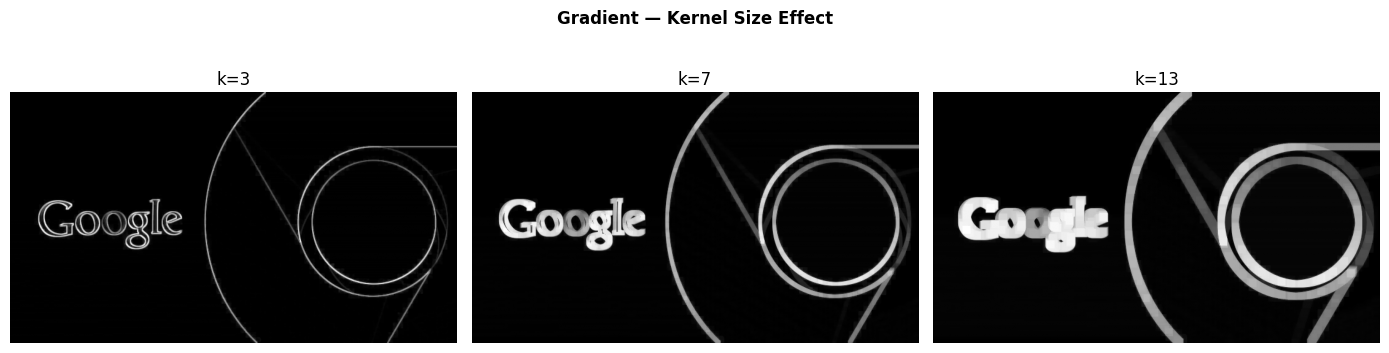

Morphological Gradient = Dilation - Erosion
It outlines object boundaries, similar to edge detection
Larger kernel = thicker, more prominent edges
Ellipse kernel = smoother, rounder outlines
Cross kernel   = outlines only along horizontal and vertical directions


In [5]:
sizes = [3, 7, 13]
grads = [cv2.morphologyEx(img, cv2.MORPH_GRADIENT, np.ones((k, k), np.uint8)) for k in sizes]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Gradient — Kernel Size Effect', fontweight='bold')
for ax, res, k in zip(axes, grads, sizes):
    ax.imshow(res, cmap='gray'); ax.set_title(f'k={k}'); ax.axis('off')
plt.tight_layout(); plt.show()

print('Morphological Gradient = Dilation - Erosion')
print('It outlines object boundaries, similar to edge detection')
print('Larger kernel = thicker, more prominent edges')
print('Ellipse kernel = smoother, rounder outlines')
print('Cross kernel   = outlines only along horizontal and vertical directions')